# Linear OT PCA on MNIST zeros

This notebook generates `fig:linear-ot-mnist-pca`.  It illustrates linear optimal transport principal components on a small collection of MNIST digit-zero histograms.  Each image is normalized as a probability density on the pixel grid.  We first compute a Sinkhorn barycenter \(\rho\), then compute entropic transport plans from \(\rho\) to each digit image and approximate the Monge maps by barycentric projections.

The displacement fields

$$
    z_i(x) = T_i(x)-x, \qquad T_i(x)=\int y\,d\pi_i(y\mid x),
$$

are represented in the weighted Hilbert space \(L^2(\rho;\mathbb R^2)\).  A standard PCA of these weighted vector fields gives the first linear-OT modes of variation of the digit-zero class.

In [1]:
from pathlib import Path
import os
import sys
import shutil
import urllib.request

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        FIGROOT = candidate.resolve()
        ROOT = FIGROOT.parent
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from IPython.display import Image, display
from sklearn.decomposition import PCA

from figure_style import figure_dir, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "linear-ot-mnist-pca"
OUT = figure_dir(NAME)
THUMB = FIGROOT / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)

## Loading MNIST and normalizing images

The notebook keeps the dataset outside the repository.  It first looks for a local cache, and downloads the standard Keras MNIST archive only if needed.  A small uniform background is added before normalization; this prevents zero-mass pixels from making Sinkhorn maps unstable while preserving the digit shape for display.

In [2]:
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
cache_candidates = []
if os.environ.get("OT4ML_MNIST_PATH"):
    cache_candidates.append(Path(os.environ["OT4ML_MNIST_PATH"]))
cache_candidates.extend([
    Path("/private/tmp/ot4ml-data/mnist.npz"),
    Path.home() / ".cache" / "ot4ml" / "mnist.npz",
])

mnist_path = next((q for q in cache_candidates if q.exists() and q.is_file()), None)
if mnist_path is None:
    mnist_path = Path.home() / ".cache" / "ot4ml" / "mnist.npz"
    mnist_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(MNIST_URL, mnist_path)

mnist = np.load(mnist_path)
zeros = mnist["x_train"][mnist["y_train"] == 0].astype(float) / 255.0

n_images = 48
selected = np.linspace(0, len(zeros) - 1, n_images, dtype=int)
images_raw = zeros[selected]
background = 0.020
images = images_raw + background
images = images / images.sum(axis=(1, 2), keepdims=True)

print(f"MNIST path: {mnist_path}")
print(f"digit-zero images: {len(zeros)}, selected: {n_images}")

MNIST path: /private/tmp/ot4ml-data/mnist.npz
digit-zero images: 5923, selected: 48


## Sinkhorn barycenter and barycentric-projection maps

The barycenter is computed by POT's convolutional Sinkhorn barycenter solver on the image grid.  For each selected image \(\alpha_i\), we solve an entropic OT problem from \(\rho\) to \(\alpha_i\).  The barycentric projection of the entropic plan gives a smooth approximate map \(T_i\), and therefore a displacement vector field \(z_i=T_i-\operatorname{Id}\).

In [3]:
height, width = images.shape[1:]
weights = np.full(n_images, 1.0 / n_images)

barycenter = ot.bregman.convolutional_barycenter2d(
    images,
    reg=0.004,
    weights=weights,
    numItermax=1000,
    stopThr=1e-7,
    verbose=False,
)
barycenter = np.maximum(barycenter, 0)
barycenter = barycenter / barycenter.sum()

xx, yy = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))
coords = np.column_stack([xx.ravel(), yy.ravel()])
ref = barycenter.ravel()
ref = ref / ref.sum()
C = ot.dist(coords, coords, metric="sqeuclidean")

reg_map = 0.004
fields = []
features = []
for k, img in enumerate(images):
    target = img.ravel()
    target = target / target.sum()
    P = ot.sinkhorn(ref, target, C, reg_map, numItermax=900, stopThr=1e-7, verbose=False)
    T = (P @ coords) / np.maximum(ref[:, None], 1e-16)
    z = T - coords
    fields.append(z)
    features.append((np.sqrt(ref)[:, None] * z).ravel())
    if k % 12 == 0:
        marginal_error = max(np.abs(P.sum(axis=1) - ref).max(), np.abs(P.sum(axis=0) - target).max())
        print(f"map {k:02d}: marginal error {marginal_error:.2e}")

fields = np.asarray(fields)
features = np.asarray(features)
mean_feature = features.mean(axis=0)
pca = PCA(n_components=4)
pca.fit(features)
print("explained variance ratios:", np.round(pca.explained_variance_ratio_, 3))

map 00: marginal error 1.34e-08


map 12: marginal error 1.24e-08


map 24: marginal error 1.07e-08


map 36: marginal error 1.40e-08


explained variance ratios: [0.382 0.227 0.109 0.065]


## Rendering the linear-OT modes

For a mode \(e_k\), we display three pushforwards of the barycenter by

$$
    x \mapsto x + \bar z(x) + a e_k(x),
    \qquad a\in\{-2.4\sqrt{\lambda_k},0,2.4\sqrt{\lambda_k}\}.
$$

The images are rendered as normalized grayscale densities: black means zero displayed mass and white means high displayed mass.

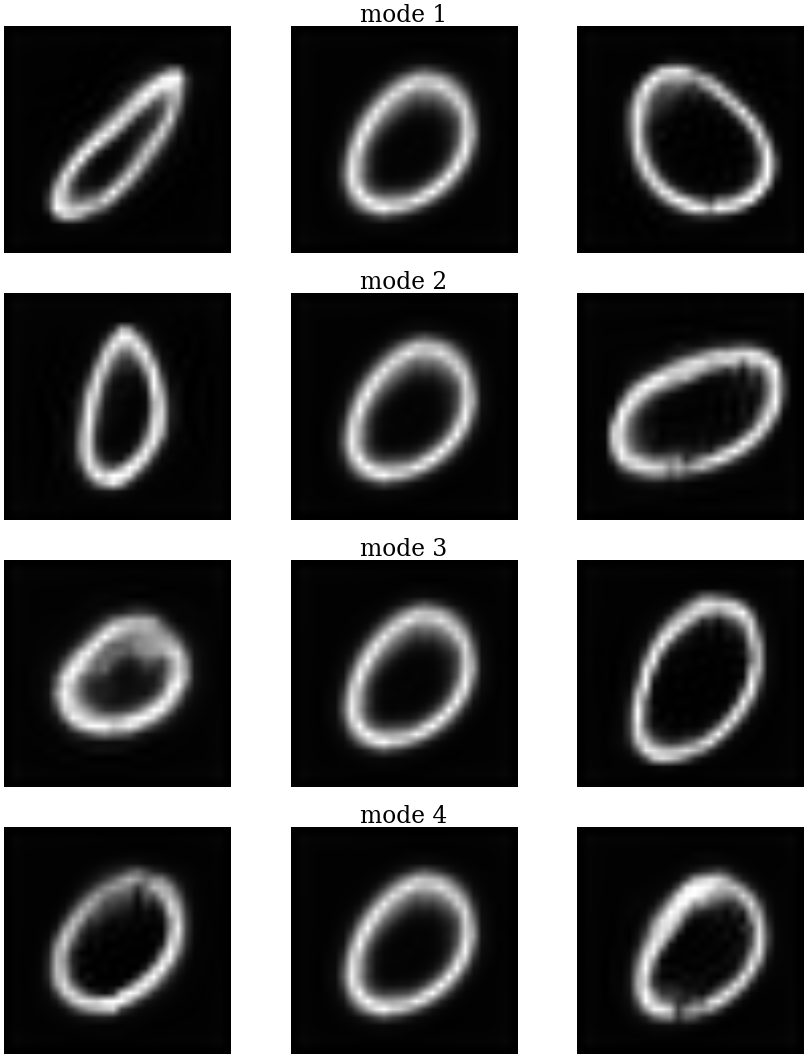

In [4]:
sqrt_ref = np.sqrt(np.maximum(ref, 1e-15))
mean_field = (mean_feature.reshape(-1, 2) / sqrt_ref[:, None])
mode_fields = [component.reshape(-1, 2) / sqrt_ref[:, None] for component in pca.components_]
mode_scales = 2.4 * np.sqrt(pca.explained_variance_)


def splat_density(points, masses):
    points = np.clip(points, 0.0, 1.0)
    px = points[:, 0] * (width - 1)
    py = points[:, 1] * (height - 1)
    x0 = np.floor(px).astype(int)
    y0 = np.floor(py).astype(int)
    x1 = np.minimum(x0 + 1, width - 1)
    y1 = np.minimum(y0 + 1, height - 1)
    wx = px - x0
    wy = py - y0
    out = np.zeros((height, width))
    np.add.at(out, (y0, x0), masses * (1 - wx) * (1 - wy))
    np.add.at(out, (y0, x1), masses * wx * (1 - wy))
    np.add.at(out, (y1, x0), masses * (1 - wx) * wy)
    np.add.at(out, (y1, x1), masses * wx * wy)
    return out


def normalize_display(img):
    img = np.maximum(img - np.percentile(img, 2), 0)
    q = np.percentile(img, 99.4)
    return np.clip(img / max(q, 1e-15), 0, 1)


def draw_digit(ax, img):
    ax.imshow(normalize_display(img), cmap="gray", vmin=0, vmax=1, interpolation="bilinear")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def render_mode(mode_index):
    mode = mode_fields[mode_index]
    scale = mode_scales[mode_index]
    densities = []
    for coeff in [-scale, 0.0, scale]:
        points = coords + mean_field + coeff * mode
        densities.append(splat_density(points, ref))
    fig, axes = plt.subplots(1, 3, figsize=(2.65, 0.95))
    for ax, density in zip(axes, densities):
        draw_digit(ax, density)
    fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99, wspace=0.02)
    return fig

# Barycenter reference panel.
fig, ax = plt.subplots(figsize=(1.05, 1.05))
draw_digit(ax, barycenter)
save_pdf(fig, OUT / "barycenter.pdf", pad_inches=0.01)
plt.close(fig)
shutil.copy2(OUT / "barycenter.pdf", ARXIV_OUT / f"{NAME}--barycenter.pdf")

for k in range(4):
    fig = render_mode(k)
    filename = f"mode-{k+1}.pdf"
    save_pdf(fig, OUT / filename, pad_inches=0.01)
    plt.close(fig)
    shutil.copy2(OUT / filename, ARXIV_OUT / f"{NAME}--{filename}")

# Gallery thumbnail: four mode triptychs with lightweight labels.
fig, axes = plt.subplots(4, 3, figsize=(4.15, 5.15))
for k in range(4):
    for j, coeff in enumerate([-mode_scales[k], 0.0, mode_scales[k]]):
        ax = axes[k, j]
        draw_digit(ax, splat_density(coords + mean_field + coeff * mode_fields[k], ref))
        if j == 1:
            ax.set_title(f"mode {k+1}", fontsize=8, pad=1)
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.96, wspace=0.02, hspace=0.18)
fig.savefig(THUMB, dpi=210, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)
display(Image(filename=str(THUMB)))

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

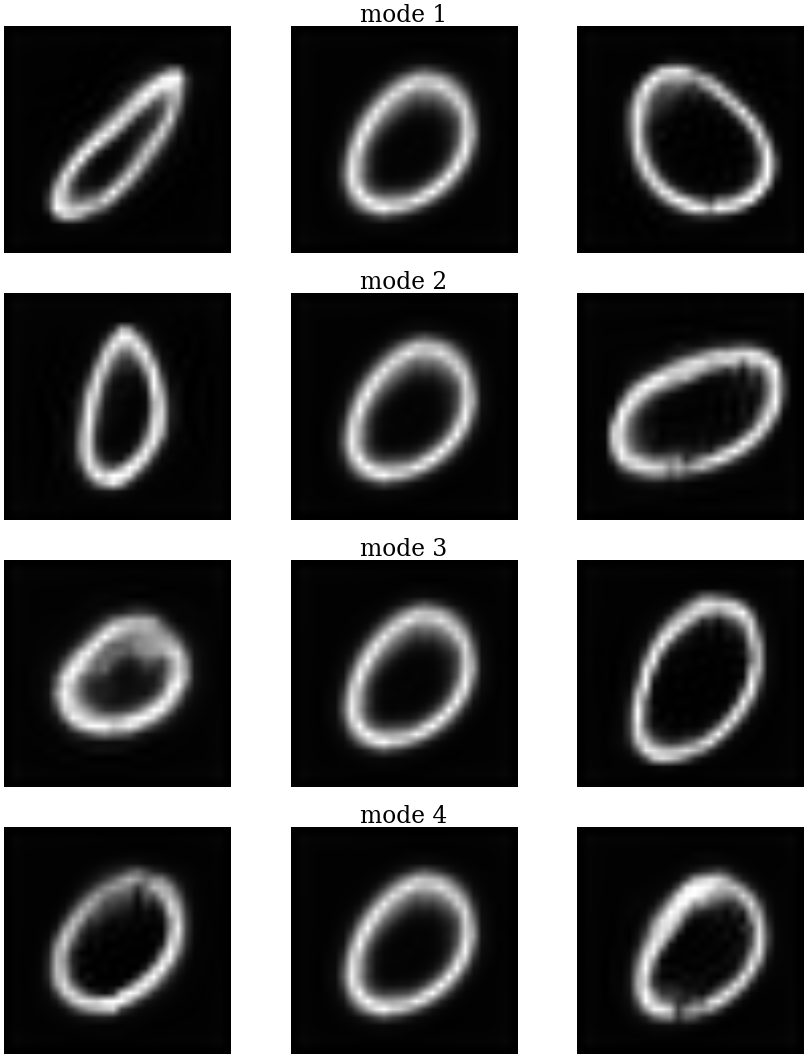

In [5]:
display(Image(filename=str(THUMB)))